# Threshold Analysis

This notebook summarizes the selected operating threshold, the validation confusion counts, and the saved ROC/DET outputs used in the publication-quality fairness report.

## Threshold summary

,metric,value
0,Threshold,0.369
1,ROC AUC,0.535
2,Estimated FAR,0.331
3,Estimated FRR,0.608
4,Overall Accuracy (initial),0.523
5,Overall Accuracy (mitigated),0.506


,class,count
0,Positive examples,"2,238"
1,Negative examples,"2,238"
2,True positive,878
3,False positive,740
4,True negative,"1,498"
5,False negative,"1,360"


**Validation pairs:** 4,476

**DET points:** 4,468

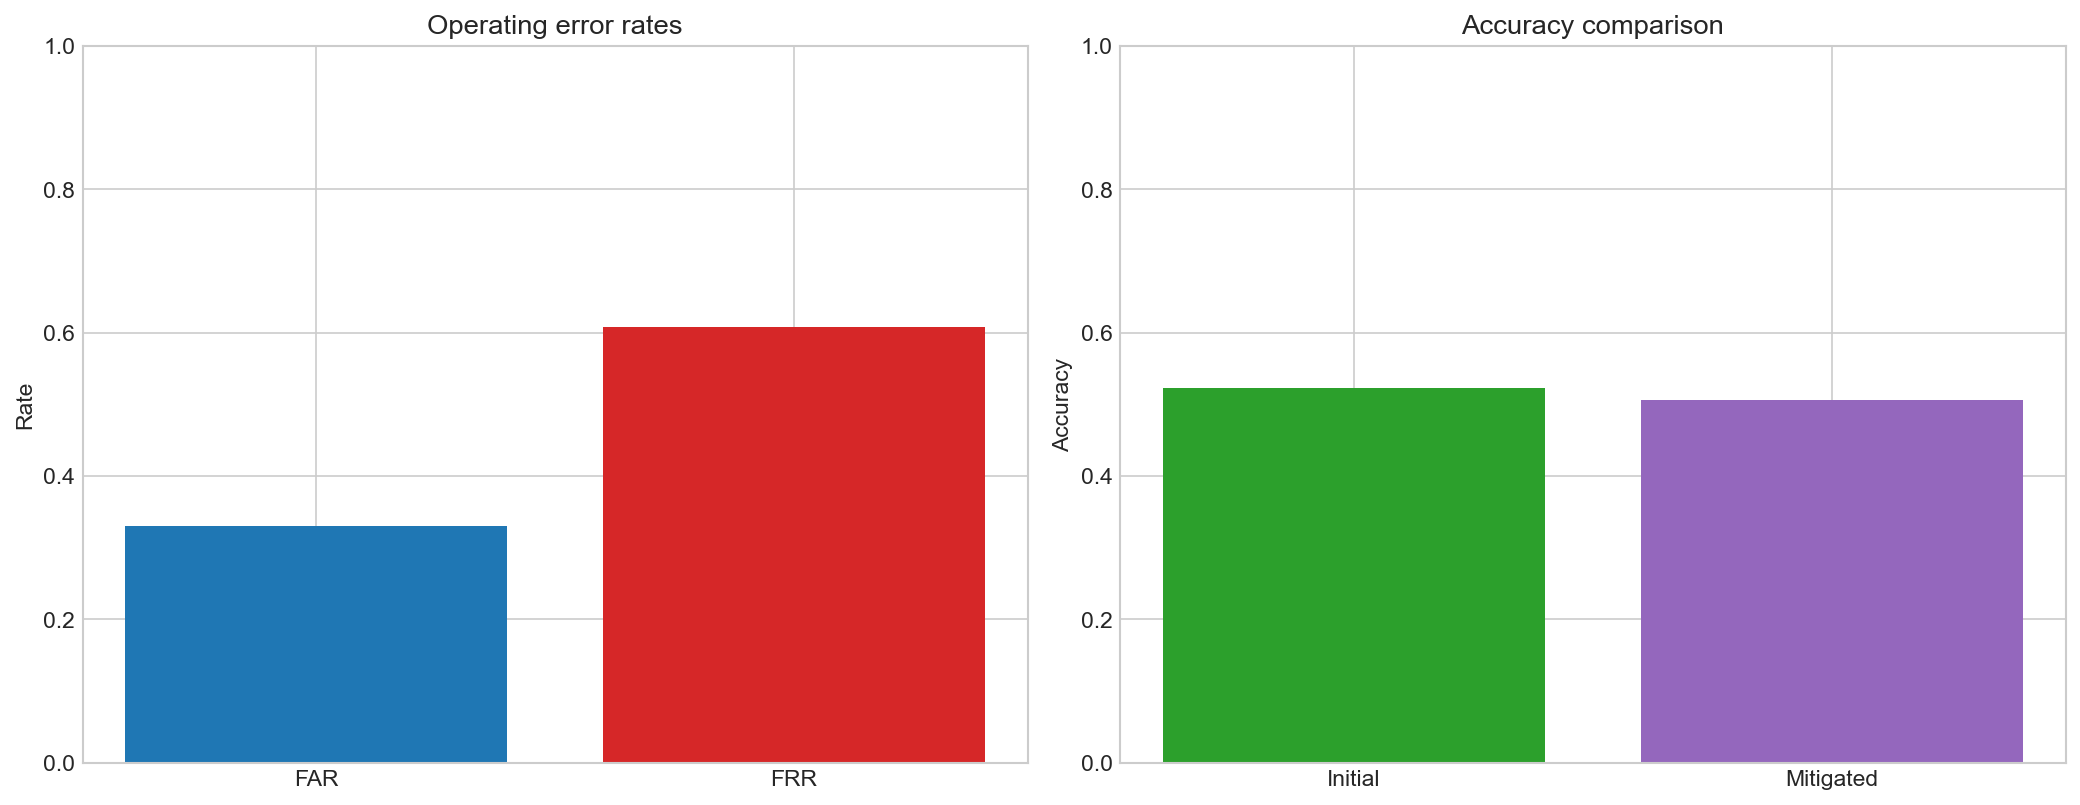

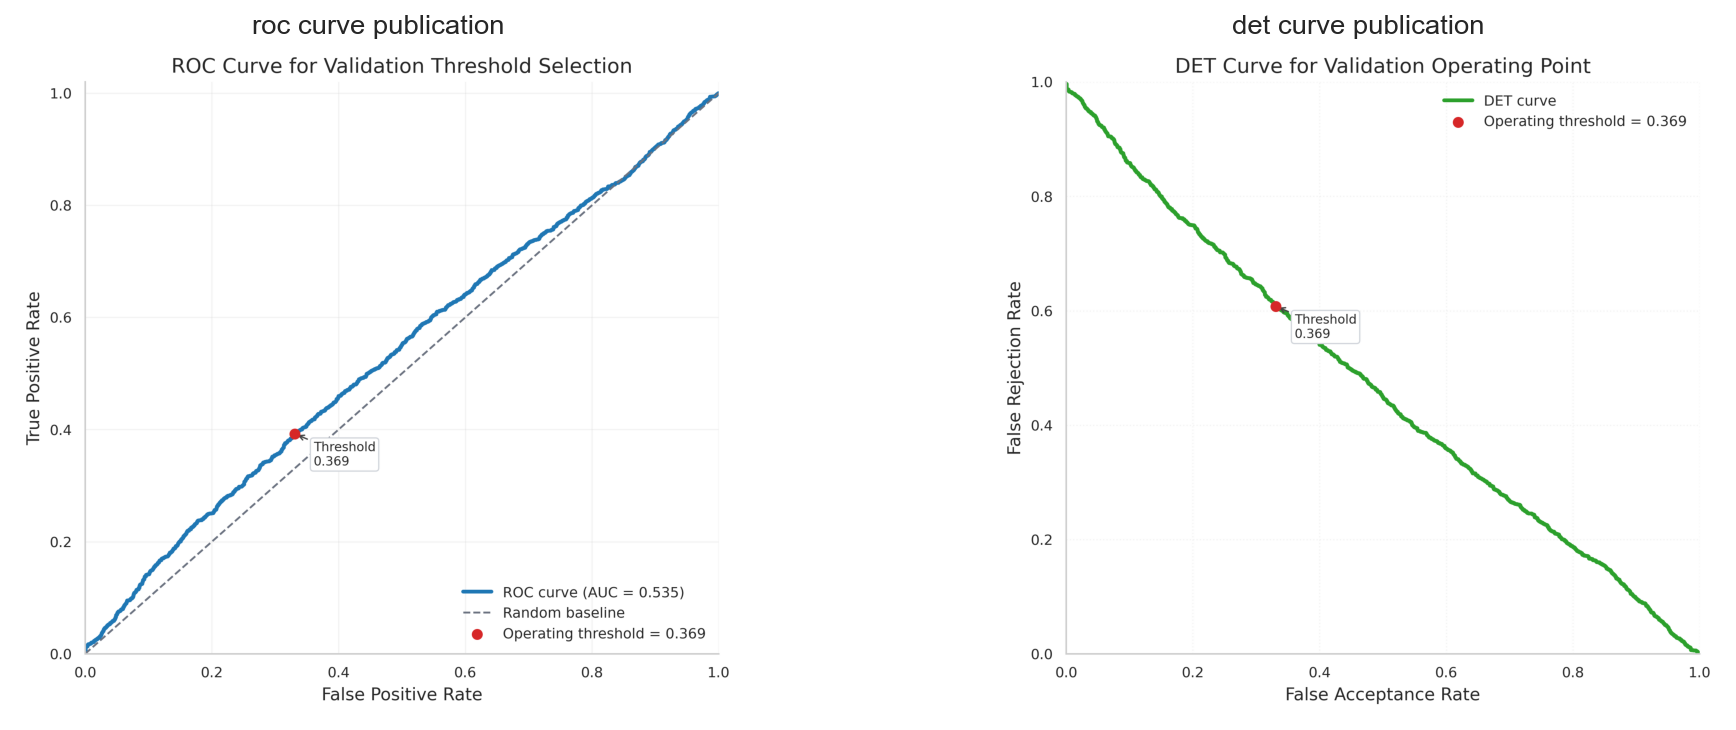

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

root = Path.cwd()
if not (root / "results").exists():
    root = root.parent

results = root / "results"
plots = root / "artifacts" / "plots"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300, "font.size": 11})


def load_json(name: str) -> dict:
    with (results / name).open("r", encoding="utf-8") as handle:
        return json.load(handle)


threshold = load_json("threshold_analysis.json")
overall = load_json("overall_metrics.json")

metrics = pd.DataFrame(
    [
        {
            "metric": "Threshold",
            "value": threshold["optimal_threshold"],
        },
        {
            "metric": "ROC AUC",
            "value": threshold["roc_auc"],
        },
        {
            "metric": "Estimated FAR",
            "value": threshold["estimated_far"],
        },
        {
            "metric": "Estimated FRR",
            "value": threshold["estimated_frr"],
        },
        {
            "metric": "Overall Accuracy (initial)",
            "value": overall["initial_model"]["accuracy"],
        },
        {
            "metric": "Overall Accuracy (mitigated)",
            "value": overall["mitigated_model"]["accuracy"],
        },
    ]
)

stats = threshold["validation_statistics"]

summary_df = pd.DataFrame(
    [
        {"class": "Positive examples", "count": stats["positive_examples"]},
        {"class": "Negative examples", "count": stats["negative_examples"]},
        {"class": "True positive", "count": stats["true_positive"]},
        {"class": "False positive", "count": stats["false_positive"]},
        {"class": "True negative", "count": stats["true_negative"]},
        {"class": "False negative", "count": stats["false_negative"]},
    ]
)

display(Markdown("## Threshold summary"))
display(metrics.style.format({"value": "{:.3f}"}))
display(summary_df.style.format({"count": "{:,.0f}"}))
display(Markdown(f"**Validation pairs:** {threshold['validation_pairs']:,}"))
display(Markdown(f"**DET points:** {threshold['det_summary']['far_points']:,}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].bar(["FAR", "FRR"], [threshold["estimated_far"], threshold["estimated_frr"]], color=["#1f77b4", "#d62728"])
axes[0].set_ylim(0, 1)
axes[0].set_title("Operating error rates")
axes[0].set_ylabel("Rate")

axes[1].bar(["Initial", "Mitigated"], [overall["initial_model"]["accuracy"], overall["mitigated_model"]["accuracy"]], color=["#2ca02c", "#9467bd"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Accuracy comparison")
axes[1].set_ylabel("Accuracy")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, name in zip(axes, ["roc_curve_publication.png", "det_curve_publication.png"]):
    axis.imshow(plt.imread(plots / name))
    axis.set_title(name.replace("_", " ").replace(".png", ""))
    axis.axis("off")

plt.tight_layout()
plt.show()